Sources
https://aboskovic21.github.io/projects/pu_gb.pdf
optuna

In [2]:


import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)
mpl.rcParams['text.usetex'] = False

In [ ]:
# Main code voor processen van de data
import uproot
import sklearn
import xgboost
import pathlib
import matplotlib.plt as plt
import scienceplots
import numpy as np
from matplotlib.plt import figure
import corner

figure(figsize=(8, 6), dpi=80)

# Background
with uproot.open(pathlib.Path(r"Training_Data\data.root")) as file:
    tree = file['treeMLDplus']
    tree.show()
    branches = tree.keys()
    print(branches)
    training_data_bkg = tree.arrays(branches, library="np")
    training_data_bkg['species'] = np.zeros(len(training_data_bkg['inv_mass']))
    # data_matrix = np.column_stack([data[b][:10000] for b in branches])

    # plt.figure(dpi=300)
    # fig = corner.corner(data_matrix, labels=branches)
    # inv_mass_training = tree.arrays(['inv_mass'],library='np')

# Signal
with uproot.open(pathlib.Path(r"Training_Data\FD.root")) as file:
    tree = file['treeMLDplus']
    tree.show()
    branches = tree.keys()
    print(branches)
    training_data_FD = tree.arrays(branches, library="np")
    training_data_FD['species'] = np.ones(len(training_data_FD['inv_mass']))
    # data_matrix = np.column_stack([data[b][:10000] for b in branches])

    # plt.figure(dpi=300)
    # fig = corner.corner(data_matrix, labels=branches)
    # inv_mass_FD = tree.arrays(['inv_mass'],library='np')


name                 | typename                 | interpretation                
---------------------+--------------------------+-------------------------------
inv_mass             | float                    | AsDtype('>f4')
pt_cand              | float                    | AsDtype('>f4')
d_len                | float                    | AsDtype('>f4')
d_len_xy             | float                    | AsDtype('>f4')
norm_dl_xy           | float                    | AsDtype('>f4')
cos_p                | float                    | AsDtype('>f4')
cos_p_xy             | float                    | AsDtype('>f4')
imp_par_xy           | float                    | AsDtype('>f4')
sig_vert             | float                    | AsDtype('>f4')
max_norm_d0d0exp     | float                    | AsDtype('>f4')
nsigComb_Pi_0        | float                    | AsDtype('>f4')
nsigComb_K_0         | float                    | AsDtype('>f4')
nsigComb_Pi_1        | float                    | AsDtype(

<Figure size 640x480 with 0 Axes>

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import xgboost as xgb

kbg_df = pd.DataFrame(training_data_FD)
FD_df = pd.DataFrame(training_data_bkg)

full_data = pd.concat([kbg_df,FD_df])


In [ ]:
from sklearn.metrics import recall_score, precision_score, roc_auc_score, accuracy_score, f1_score
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import confusion_matrix, classification_report

x_data = full_data[branches]
y_data = full_data['species']
print(set(y_data))



x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.1, random_state=7)
print(np.unique(y_train, return_counts=True))


evals_result = {}
# Settings we train the xgbclassifier with, the options we pass to the xgbclassifier are the hyperparameters we want to optimise.
pos_class_weight = 12
model = xgb.XGBClassifier(
    n_estimators=8,
    objective='binary:logistic',
    scale_pos_weight=pos_class_weight,
    max_delta_step=1,
    random_state=42,
    eval_metric=f1_score
    
)
model.fit(x_train, y_train, 
          eval_set=[(x_train, y_train), (x_test, y_test)],
    verbose=False
    )

{0.0, 1.0}
(array([0., 1.]), array([4209487,    5159]))


Confusion Matrix:
[[467675      6]
 [   198    415]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    467681
         1.0       0.99      0.68      0.80       613

    accuracy                           1.00    468294
   macro avg       0.99      0.84      0.90    468294
weighted avg       1.00      1.00      1.00    468294



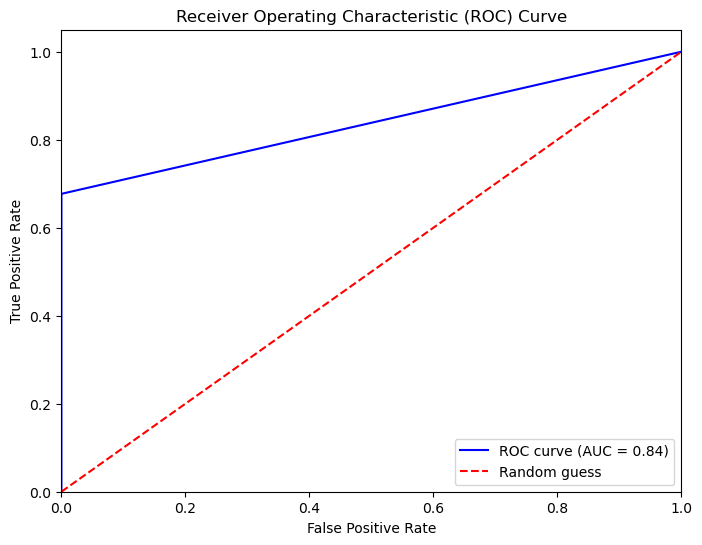

Classification results:
f1: 80.27%
roc: 83.85%
recall: 67.70%
precision: 98.57%
None


XGBoostError: No evaluation result, `eval_set` is not used during training.

In [ ]:

# Define a function to evaluate the results
def evaluate_results(y_test, y_predict):
    print('Classification results:')
    f1 = f1_score(y_test, y_predict)
    print("f1: %.2f%%" % (f1 * 100.0)) 
    roc = roc_auc_score(y_test, y_predict)
    print("roc: %.2f%%" % (roc * 100.0)) 
    rec = recall_score(y_test, y_predict, average='binary')
    print("recall: %.2f%%" % (rec * 100.0)) 
    prc = precision_score(y_test, y_predict, average='binary')
    print("precision: %.2f%%" % (prc * 100.0))

# Evaluate the model
predictions = model.predict(x_test)
print("Confusion Matrix:")
print(confusion_matrix(y_test, predictions))
print("\nClassification Report:")
print(classification_report(y_test, predictions))

# Make predictions on the testing set and evaluate the results
y_predict = model.predict(x_test)
fpr, tpr, thresholds = roc_curve(y_test, y_predict)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()
print(evaluate_results(y_test, y_predict))

results = model.evals_result()
epochs = len(results['validation_0']['error'])
x_axis = range(0, epochs)

fig, ax = plt.subplots()
ax.plot(x_axis, results['validation_0']['auc'], label='Train')
ax.plot(x_axis, results['validation_1']['auc'], label='Test')
ax.legend()
plt.ylabel('AUC')
plt.title('XGBoost AUC')
plt.show()

In [ ]:
import optuna
# Define an objective function. This will find how good the model is performing, based on different hyperparameters.
# Using this function optuna will sample the hyperparameterspace to find the best hyperparameters for training.


x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.2, random_state=7)
print(np.unique(y_train, return_counts=True))

# Settings we train the xgbclassifier with, the options we pass to the xgbclassifier are the hyperparameters we want to optimise.
pos_class_weight = len(training_data_FD['inv_mass'])/len(training_data_bkg['inv_mass'])*10000
print(pos_class_weight)
model = xgb.XGBClassifier(
    n_estimators=100,
    objective='binary:logistic',
    scale_pos_weight=pos_class_weight,
    max_delta_step=1,
    random_state=42
)
model.fit(x_train, y_train)


def objective(trial):
    data, target =  full_data[branches], full_data['species']
    train_x, test_x, train_y, test_y = train_test_split(data, target, test_size=0.25)
    dtrain = xgb.DMatrix(train_x, label=train_y)
    dtest = xgb.DMatrix(test_x, label=test_y)

    param = {
        "silent": 1,
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "booster": trial.suggest_categorical("booster", ["gbtree", "gblinear", "dart"]),
        "lambda": trial.suggest_float("lambda", 1e-8, 1.0,log=True),
        "alpha": trial.suggest_float("alpha", 1e-8, 1.0,log=True),
    }

    if param["booster"] == "gbtree" or param["booster"] == "dart":
        param["max_depth"] = trial.suggest_int("max_depth", 1, 9)
        param["eta"] = trial.suggest_float("eta", 1e-8, 1.0,log=True)
        param["gamma"] = trial.suggest_float("gamma", 1e-8, 1.0,log=True)
        param["grow_policy"] = trial.suggest_categorical("grow_policy", ["depthwise", "lossguide"])
    if param["booster"] == "dart":
        param["sample_type"] = trial.suggest_categorical("sample_type", ["uniform", "weighted"])
        param["normalize_type"] = trial.suggest_categorical("normalize_type", ["tree", "forest"])
        param["rate_drop"] = trial.suggest_float("rate_drop", 1e-8, 1.0,log=True)
        param["skip_drop"] = trial.suggest_float("skip_drop", 1e-8, 1.0,log=True)

    # Add a callback for pruning.
    # We are sampling the hyperparameterspace for what combination of hyperparameters results in a fast learning algorithm
    # For samples that learn very slowly, we do not need to train them for many epochs
    pruning_callback = optuna.integration.XGBoostPruningCallback(trial, "validation-auc")
    bst = xgb.train(param, dtrain, evals=[(dtest, "validation")], callbacks=[pruning_callback])
    preds = bst.predict(dtest)
    pred_labels = np.rint(preds)
    accuracy = sklearn.metrics.f1_score(test_y, pred_labels) # F1 score voor ongebalanceerde data
    # Let op met welke metric we gebruiken als accuracy hier. Omdat de dataset heel ongebalanceerd is, 
    # moedigen we hier modellen aan die alles klassificeren als geen D+ deeltje, omdat dat al best goed in de buurt van het juiste antwoord is
    # We hebben immers veel minder D+ deeltjes
    return accuracy

study = optuna.create_study()
study.optimize(objective, n_trials=30)
print(study.best_trial)

[I 2025-11-26 14:17:15,314] A new study created in memory with name: no-name-1ef1a91e-ea80-4213-ae87-6372e89af97b


(array([0., 1.]), array([3741792,    4560]))
12.340801100152914


c:\Users\sande\anaconda3\envs\CAML\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:17:17] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "silent" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[0]	validation-auc:0.97832
[1]	validation-auc:0.98503
[2]	validation-auc:0.98963
[3]	validation-auc:0.99188
[4]	validation-auc:0.99511
[5]	validation-auc:0.99552
[6]	validation-auc:0.99573
[7]	validation-auc:0.99581
[8]	validation-auc:0.99569
[9]	validation-auc:0.99620


[I 2025-11-26 14:17:26,180] Trial 0 finished with value: 0.4263581094332222 and parameters: {'scale_pos_weight': 19.08692736035503}. Best is trial 0 with value: 0.4263581094332222.
c:\Users\sande\anaconda3\envs\CAML\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:17:30] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "silent" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


...

[0]	validation-auc:0.96910
[1]	validation-auc:0.97986
[2]	validation-auc:0.98155
[3]	validation-auc:0.98889
[4]	validation-auc:0.99083
[5]	validation-auc:0.99184
[6]	validation-auc:0.99313
[7]	validation-auc:0.99338
[8]	validation-auc:0.99422
[9]	validation-auc:0.99436


[I 2025-11-26 14:21:08,753] Trial 26 finished with value: 0.5816084153376315 and parameters: {'scale_pos_weight': 3.1464879511080497}. Best is trial 3 with value: 0.2924865831842576.
c:\Users\sande\anaconda3\envs\CAML\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:21:11] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "silent" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
[I 2025-11-26 14:21:14,835] Trial 27 pruned. Trial was pruned at iteration 0.
c:\Users\sande\anaconda3\envs\CAML\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:21:17] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "silent" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[0]	validation-auc:0.94364
[1]	validation-auc:0.95439
[2]	validation-auc:0.95582
[3]	validation-auc:0.98060
[4]	validation-auc:0.98228
[5]	validation-auc:0.98390
[6]	validation-auc:0.98392
[7]	validation-auc:0.98504
[8]	validation-auc:0.98821
[9]	validation-auc:0.98846


[I 2025-11-26 14:21:24,105] Trial 28 finished with value: 0.4854716137684399 and parameters: {'scale_pos_weight': 1.022551224714681}. Best is trial 3 with value: 0.2924865831842576.
c:\Users\sande\anaconda3\envs\CAML\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:21:26] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "silent" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
[I 2025-11-26 14:21:30,001] Trial 29 pruned. Trial was pruned at iteration 0.


FrozenTrial(number=3, state=1, values=[0.2924865831842576], datetime_start=datetime.datetime(2025, 11, 26, 14, 18, 3, 256890), datetime_complete=datetime.datetime(2025, 11, 26, 14, 18, 15, 275346), params={'scale_pos_weight': 60.7867945250717}, user_attrs={}, system_attrs={}, intermediate_values={0: 0.9886777895120268, 1: 0.9895315679876088, 2: 0.9916922103132858, 3: 0.9934785153593847, 4: 0.9940733241711446, 5: 0.9957496378927788, 6: 0.99584109752207, 7: 0.9965215882519562, 8: 0.9967125601242498, 9: 0.996814250404819}, distributions={'scale_pos_weight': FloatDistribution(high=100.0, log=True, low=1.0, step=None)}, trial_id=3, value=None)


In [10]:
import plotly
df = study.trials_dataframe()

best = study.best_trial

data = {
    "value": best.value,
    "params": best.params,
    "user_attrs": best.user_attrs,
    "system_attrs": best.system_attrs
}

objective(best)

c:\Users\sande\anaconda3\envs\CAML\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:43:00] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "silent" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[0]	validation-auc:0.98540
[1]	validation-auc:0.98901
[2]	validation-auc:0.99139
[3]	validation-auc:0.99246
[4]	validation-auc:0.99531
[5]	validation-auc:0.99555
[6]	validation-auc:0.99569
[7]	validation-auc:0.99636
[8]	validation-auc:0.99640
[9]	validation-auc:0.99655


0.2855811786629397

In [11]:
import optuna
import optuna_integration
from plotly.io import show
# https://optuna.readthedocs.io/en/stable/reference/visualization/index.html

fig = optuna.visualization.plot_param_importances(study)
show(fig)
fig = optuna.visualization.plot_intermediate_values(study)
show(fig)
fig = optuna.visualization.plot_timeline(study)
show(fig)

In [13]:

#https://www.geeksforgeeks.org/machine-learning/handling-imbalanced-data-for-classification/
best_params = study.best_params
print(best_params)
model = xgb.XGBClassifier(**best_params
)
model.fit(x_train, y_train)
pred = model.predict(x_test)
print(classification_report(y_test, pred))
evaluate_results(y_test, pred)

{'scale_pos_weight': 60.7867945250717}
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    935376
         1.0       0.33      0.84      0.48      1212

    accuracy                           1.00    936588
   macro avg       0.67      0.92      0.74    936588
weighted avg       1.00      1.00      1.00    936588

Classification results:
f1: 47.59%
roc: 91.72%
recall: 83.66%
precision: 33.26%
